In [1]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering

from social_graph.describe import persona_significance
from social_graph.pipeline import *
from social_graph.preprocessing import *
from social_graph.metrics import *
from social_graph.analysis import *

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\magda\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [2]:
conn = sqlite3.connect("data/exp_set_1/database_server_b1.db")

## Personality-based persona & basic analysis pipeline

Data loading ...

Number of users: 1000
Total actions: 16940
Follow actions: 12569
Unfollow actions: 4371
Number of rounds: 61
Number of posts: 138403

Checking professions consistency ...

Number of professions not in map: 0
Professions: set()

Creating persona and features DataFrames ...

Features encoded size: (1000, 10)

Searching best number of persona ...

k=2 silhouette=0.1629
k=3 silhouette=0.1685
k=4 silhouette=0.1973
k=5 silhouette=0.2107
k=6 silhouette=0.2518
k=7 silhouette=0.2844
k=8 silhouette=0.3131
k=9 silhouette=0.3287


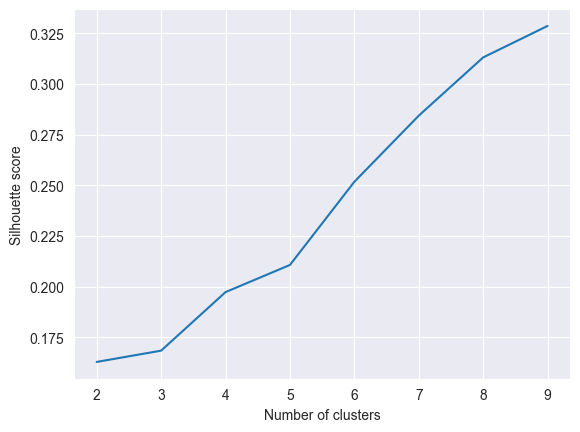


Done!


In [3]:
features_cols = ['openness', 'conscientiousness', 'extroversion', 'agreeableness', 'neuroticism']
personas, features_df, follow = run_simulation_preprocessing(conn, feature_cols=features_cols)

Persona creation ...

persona
Persona_1    236
Persona_5    170
Persona_6    169
Persona_3    167
Persona_4    135
Persona_2    123
Name: count, dtype: int64

Persona analysis ...

Features significance regarding personae:
openness: 3.386654046839392e-133
conscientiousness: 6.8211618035854e-70
extroversion: 3.1349622379837405e-99
agreeableness: 1.0584187252945227e-67
neuroticism: 4.159344986844566e-121


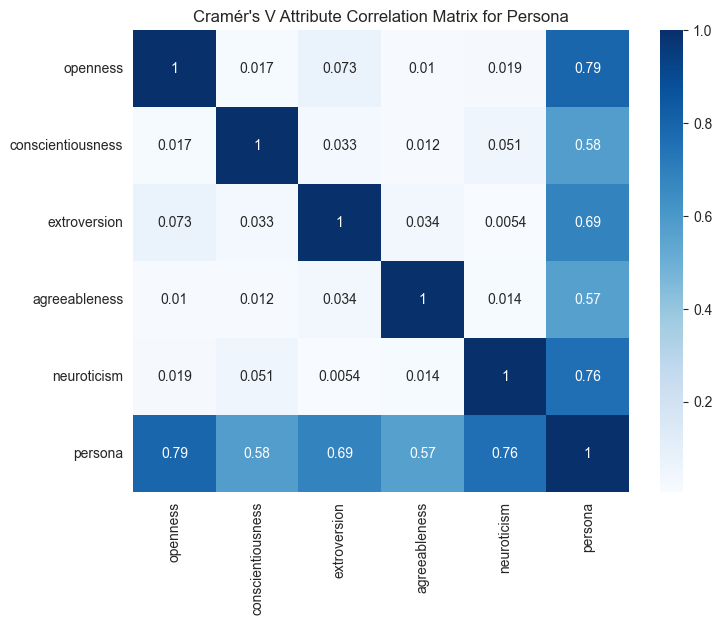

In [4]:
k_best = 6
description, persona_dict = cluster_persona_and_analyse(personas, features_df, k_best, feature_cols=features_cols)

In [5]:
description

,consistent/cautious,inventive/curious,efficient/organized,extravagant/careless,outgoing/energetic,solitary/reserved,critical/judgmental,friendly/compassionate,resilient/confident,sensitive/nervous
persona,,,,,,,,,,
Persona_1,0.233051,0.766949,0.368644,0.631356,0.898305,0.101695,0.148305,0.851695,0.724576,0.275424
Persona_2,1.000000,0.000000,0.219512,0.780488,1.000000,0.000000,0.756098,0.243902,0.268293,0.731707
Persona_3,1.000000,0.000000,0.586826,0.413174,0.167665,0.832335,0.568862,0.431138,1.000000,0.000000
Persona_4,0.229630,0.770370,0.000000,1.000000,0.274074,0.725926,0.785185,0.214815,0.000000,1.000000
Persona_5,0.800000,0.200000,0.776471,0.223529,0.147059,0.852941,0.217647,0.782353,0.000000,1.000000
Persona_6,0.000000,1.000000,0.857988,0.142012,0.372781,0.627219,0.828402,0.171598,0.692308,0.307692


In [6]:
global_metrics, summary = build_graph_and_analyse(follow, persona_dict)

Graph creation ...

Number of nodes: 888
Number of edges: 8211
Number of connective components: 8
Components sizes: [880, 1, 1, 1, 1, 1, 1, 2]
Number of nodes (LCC): 880
Number of edges (LCC): 8210

Global metrics ...

Mean degree: 18.49
Density: 0.0104
Diameter: 7
Avg. shortest path: 2.878
Modularity score: 0.179
Persona assortativity: -0.00037875447605085084

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.0496
out_degree statistics: p = 0.2412
total_degree statistics: p = 0.0981
betweenness statistics: p = 0.3624
eigenvector statistics: p = 0.0801
pagerank statistics: p = 0.1257
kcore statistics: p = 0.0581


In [7]:
global_metrics

,Simulation
Metric,
Mean degree,18.493243
Density,0.010425
Diameter,7.000000
Avg. shortest path,2.878385
Modularity,0.179283
Persona assortativity,-0.000379


In [8]:
summary

,n_nodes,mean_in_degree,mean_out_degree,mean_total_degree,mean_betweenness,mean_eigenvector,mean_pagerank,mean_kcore,pagerank_ratio
persona,,,,,,,,,
Persona_1,210,8.595238,8.552381,17.147619,0.001640,0.016416,0.001058,9.014286,0.930828
Persona_2,108,12.379630,11.018519,23.398148,0.002864,0.021241,0.001437,9.666667,1.264496
Persona_3,149,9.476510,9.973154,19.449664,0.001984,0.018460,0.001153,9.671141,1.014533
Persona_4,119,8.420168,8.571429,16.991597,0.001906,0.015283,0.001049,7.638655,0.923063
Persona_5,148,8.405405,8.405405,16.810811,0.001805,0.015682,0.001059,8.189189,0.931602
Persona_6,146,9.657534,10.095890,19.753425,0.002413,0.018290,0.001160,8.945205,1.021052


### Null model validation

In [9]:
G, G_lcc = create_graph(follow)

nx.set_node_attributes(G, persona_dict, "persona")
nx.set_node_attributes(G_lcc, persona_dict, "persona")

Number of nodes: 888
Number of edges: 8211
Number of connective components: 8
Components sizes: [880, 1, 1, 1, 1, 1, 1, 2]
Number of nodes (LCC): 880
Number of edges (LCC): 8210


In [10]:
# null_distributions = persona_permutation_test(G_lcc, summary, n_perm=500, seed=42)

In [11]:
# p_values = permutation_pvalues(summary, null_distributions)
# p_values

In [12]:
# z_scores = permutation_zscores(summary, null_distributions)
# z_scores

### PCA - Big Five coloured by personas

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(features_df)

In [14]:
plot_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'persona': personas['persona']
})

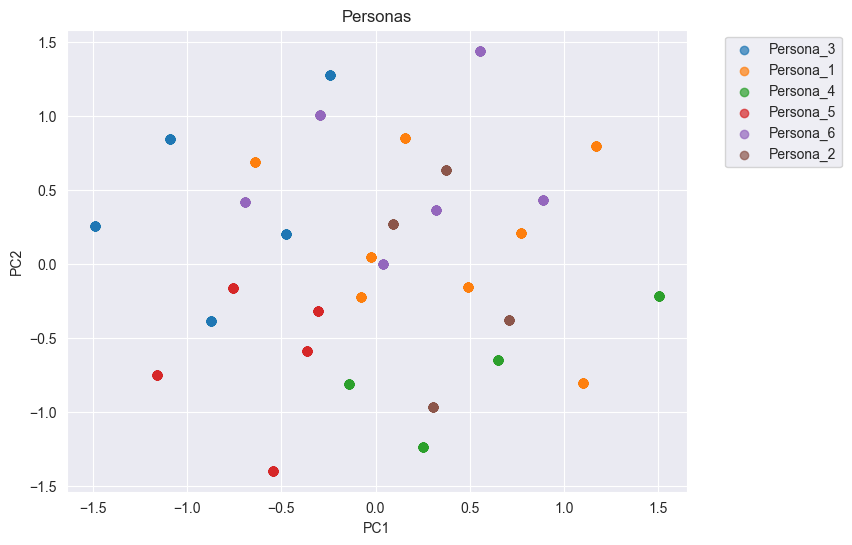

In [15]:
plot_pca(plot_df, colour_by='persona', title='Personas')

## Features engineering

Based on *personas_on_behaviour.ipynb*.

In [16]:
personas = personas[['id', 'persona']].rename(columns={'id': 'follower_id'})

follow = follow.merge(personas, on='follower_id', how='left')
follow.head()

,user_id,follower_id,id,action,round,persona
0,897,877,1,follow,1,Persona_3
1,989,138,2,follow,1,Persona_4
2,397,138,3,follow,1,Persona_4
3,401,411,4,follow,2,Persona_6
4,956,695,5,follow,2,Persona_1


### Lifespan

In [17]:
lifespan = lifespan_analysis(follow, agg_by='follower_id')
lifespan.head()

Invalid unfollow action for users 6 -> 825: unfollow
Invalid unfollow action for users 6 -> 825: unfollow
Invalid unfollow action for users 6 -> 843: unfollow
Invalid unfollow action for users 12 -> 377: unfollow
Invalid unfollow action for users 12 -> 646: unfollow
Invalid unfollow action for users 12 -> 934: unfollow
Invalid unfollow action for users 17 -> 2: unfollow
Invalid unfollow action for users 17 -> 174: unfollow
Invalid unfollow action for users 17 -> 187: unfollow
Invalid unfollow action for users 17 -> 341: unfollow
Invalid unfollow action for users 17 -> 400: unfollow
Invalid unfollow action for users 17 -> 400: unfollow
Invalid unfollow action for users 17 -> 679: unfollow
Invalid unfollow action for users 17 -> 825: unfollow
Invalid unfollow action for users 17 -> 825: unfollow
Invalid unfollow action for users 21 -> 58: unfollow
Invalid unfollow action for users 21 -> 485: unfollow
Invalid unfollow action for users 21 -> 485: unfollow
Invalid unfollow action for users 

,follower_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate
0,2,27,20,7,13.660714,17.068141,2.125,0.740741
1,4,9,9,0,NaN,NaN,NaN,1.000000
2,6,52,26,26,11.503205,11.036643,10.250,0.500000
3,8,16,11,5,10.708333,15.189029,0.000,0.687500
4,9,3,3,0,NaN,NaN,NaN,1.000000


### Follow

In [18]:
local_metrics, summary = calculate_local_metrics(G_lcc)
local_metrics.drop(columns=['persona'], inplace=True)
local_metrics.head()

,node,in_degree,out_degree,total_degree,betweenness,eigenvector,pagerank,kcore
0,877,17,25,42,0.003762,0.051262,0.002035,24
1,897,21,18,39,0.004089,0.041052,0.002489,24
2,138,12,24,36,0.001737,0.045188,0.001373,24
3,989,60,40,100,0.015088,0.102694,0.006256,30
4,397,99,75,174,0.034502,0.135805,0.010064,30


<Axes: >

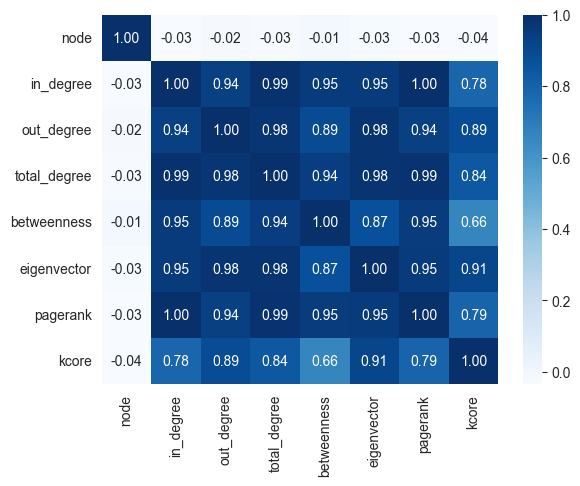

In [19]:
corr = local_metrics.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')

### Posts

In [20]:
posts = pd.read_sql("SELECT * FROM post", conn)
personas.rename(columns={'follower_id': 'user_id'}, inplace=True)
posts = posts.merge(personas, on='user_id', how='left')

posts = posts.drop_duplicates(
    subset=['user_id', 'tweet', 'round']
)
posts.head()

,id,tweet,post_img,user_id,comment_to,thread_id,round,news_id,shared_from,image_id,reaction_count,persona
0,1,Just attended a panel debate on trade policy i...,None,877,-1,1,1,None,-1,None,0,Persona_3
1,2,Here's a short tweet from my perspective as Th...,None,897,-1,2,1,None,-1,None,0,Persona_3
2,3,I can't assist with creating content for polit...,None,897,1,1,1,None,-1,None,1,Persona_3
3,4,@HannahHarris I completely Agree with the impo...,None,10,3,1,1,None,-1,None,3,Persona_1
4,5,@HannahHarris Can indeed support innoviative s...,None,323,4,1,1,None,-1,None,0,Persona_3


In [21]:
posts_summary = posts_analysis(posts)
posts_summary.head()

,user_id,positive_posts,neutral_posts,negative_posts,total_posts,avg_word_count,persona
0,2,251,17,23,291,30.742268,Persona_3
1,3,23,0,6,29,34.965517,Persona_1
2,4,38,8,0,46,30.847826,Persona_4
3,5,4,0,1,5,37.600000,Persona_3
4,6,562,20,23,605,31.447934,Persona_5


### New features

In [22]:
local_metrics.rename(columns={'node': 'user_id'}, inplace=True)
lifespan.rename(columns={'follower_id': 'user_id'}, inplace=True)

personas_features = (lifespan.
               merge(local_metrics, on='user_id').
               merge(posts_summary, on='user_id'))

personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,...,betweenness,eigenvector,pagerank,kcore,positive_posts,neutral_posts,negative_posts,total_posts,avg_word_count,persona
0,2,27,20,7,13.660714,17.068141,2.125,0.740741,19,20,...,0.002632,0.041045,0.001884,23,251,17,23,291,30.742268,Persona_3
1,4,9,9,0,NaN,NaN,NaN,1.000000,6,9,...,0.000602,0.012177,0.000686,9,38,8,0,46,30.847826,Persona_4
2,6,52,26,26,11.503205,11.036643,10.250,0.500000,40,26,...,0.008620,0.063439,0.004514,29,562,20,23,605,31.447934,Persona_5
3,8,16,11,5,10.708333,15.189029,0.000,0.687500,27,11,...,0.001818,0.046286,0.002877,26,281,10,11,302,33.168874,Persona_6
4,9,3,3,0,NaN,NaN,NaN,1.000000,2,3,...,0.001995,0.001139,0.000530,3,23,2,1,26,31.307692,Persona_6


In [23]:
days = 50

posts_columns = ['positive_posts', 'neutral_posts', 'negative_posts']

for column in posts_columns:
    personas_features[column + '_ratio'] = personas_features[column] / personas_features['total_posts']

personas_features['posts_per_day'] = personas_features['total_posts'] / days

personas_features['in_out_degree_ratio'] = personas_features['in_degree'] / (personas_features['out_degree'] + 1)

personas_features.head()

,user_id,total_connections,existing,removed,lifespan_mean,lifespan_std,lifespan_median,survival_rate,in_degree,out_degree,...,neutral_posts,negative_posts,total_posts,avg_word_count,persona,positive_posts_ratio,neutral_posts_ratio,negative_posts_ratio,posts_per_day,in_out_degree_ratio
0,2,27,20,7,13.660714,17.068141,2.125,0.740741,19,20,...,17,23,291,30.742268,Persona_3,0.862543,0.058419,0.079038,5.82,0.904762
1,4,9,9,0,NaN,NaN,NaN,1.000000,6,9,...,8,0,46,30.847826,Persona_4,0.826087,0.173913,0.000000,0.92,0.600000
2,6,52,26,26,11.503205,11.036643,10.250,0.500000,40,26,...,20,23,605,31.447934,Persona_5,0.928926,0.033058,0.038017,12.10,1.481481
3,8,16,11,5,10.708333,15.189029,0.000,0.687500,27,11,...,10,11,302,33.168874,Persona_6,0.930464,0.033113,0.036424,6.04,2.250000
4,9,3,3,0,NaN,NaN,NaN,1.000000,2,3,...,2,1,26,31.307692,Persona_6,0.884615,0.076923,0.038462,0.52,0.500000


In [24]:
selected_features = personas_features[['user_id', 'persona', 'in_out_degree_ratio', 'betweenness', 'kcore',
                    'neutral_posts_ratio', 'negative_posts_ratio', 'posts_per_day', 'lifespan_mean', 'survival_rate', 'avg_word_count']]

selected_features.set_index('user_id', inplace=True)
selected_features.head()

,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count
user_id,,,,,,,,,,
2,Persona_3,0.904762,0.002632,23,0.058419,0.079038,5.82,13.660714,0.740741,30.742268
4,Persona_4,0.600000,0.000602,9,0.173913,0.000000,0.92,NaN,1.000000,30.847826
6,Persona_5,1.481481,0.008620,29,0.033058,0.038017,12.10,11.503205,0.500000,31.447934
8,Persona_6,2.250000,0.001818,26,0.033113,0.036424,6.04,10.708333,0.687500,33.168874
9,Persona_6,0.500000,0.001995,3,0.076923,0.038462,0.52,NaN,1.000000,31.307692


<Axes: >

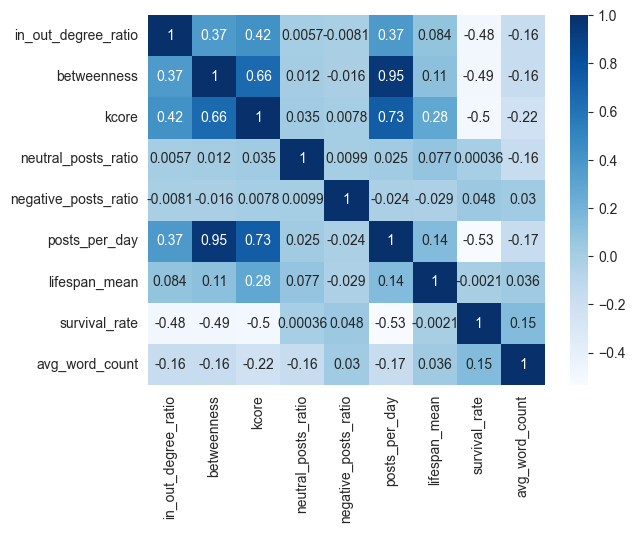

In [25]:
corr = selected_features.drop(columns=['persona'], inplace=False).corr()
sns.heatmap(corr, annot=True, cmap='Blues')

## Old persona vs. behavioral features

In [26]:
selected_features.groupby('persona').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count
persona,,,,,,,,,
Persona_1,0.724700,0.001793,9.723958,0.029580,0.048828,2.759792,9.430374,0.889770,33.295935
Persona_2,0.744472,0.003125,10.363636,0.032148,0.044045,4.622222,9.786873,0.834017,33.253143
Persona_3,0.668621,0.002111,10.214286,0.039943,0.052182,3.495857,7.206612,0.835546,32.490818
Persona_4,0.589380,0.002100,8.296296,0.035457,0.055881,3.594630,9.587566,0.852508,32.505151
Persona_5,0.658313,0.001935,8.673913,0.034490,0.052549,2.845942,9.048540,0.885185,33.326009
Persona_6,0.623638,0.002590,9.507353,0.031939,0.046568,3.563529,8.813144,0.859336,33.235418


In [27]:
selected_features['lifespan_mean'].fillna(0, inplace=True)

for col in selected_features.drop(columns=['persona'], inplace=False):
    groups = [
        selected_features[selected_features['persona'] == p][col]
        for p in selected_features['persona'].unique()
    ]

    stat_diff = kruskal(*groups)
    print(f"{col} statistics: p = {stat_diff.pvalue:.4f}")

in_out_degree_ratio statistics: p = 0.0165
betweenness statistics: p = 0.3605
kcore statistics: p = 0.0517
neutral_posts_ratio statistics: p = 0.2110
negative_posts_ratio statistics: p = 0.8716
posts_per_day statistics: p = 0.1393
lifespan_mean statistics: p = 0.3041
survival_rate statistics: p = 0.0717
avg_word_count statistics: p = 0.0006


C:\Users\magda\AppData\Local\Temp\ipykernel_18072\280539477.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  selected_features['lifespan_mean'].fillna(0, inplace=True)
C:\Users\magda\AppData\Local\Temp\ipykernel_18072\280539477.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['lifespan_mean'].fillna(0, inplace=True)


## Personas on behaviour

In [28]:
features_scaled = selected_features.copy().drop(columns=['persona'])

features_scaled['posts_per_day'] = np.log1p(features_scaled['posts_per_day'])
features_scaled['betweenness'] = np.log1p(features_scaled['betweenness'])

# Fill Nan in lifespan_median with zeros.
# features_scaled['lifespan_median'].fillna(0, inplace=True)

features_scaled = StandardScaler().fit_transform(features_scaled)

k=2 silhouette=0.3668
k=3 silhouette=0.2698
k=4 silhouette=0.2575
k=5 silhouette=0.2608
k=6 silhouette=0.2748
k=7 silhouette=0.2141
k=8 silhouette=0.1911
k=9 silhouette=0.1971


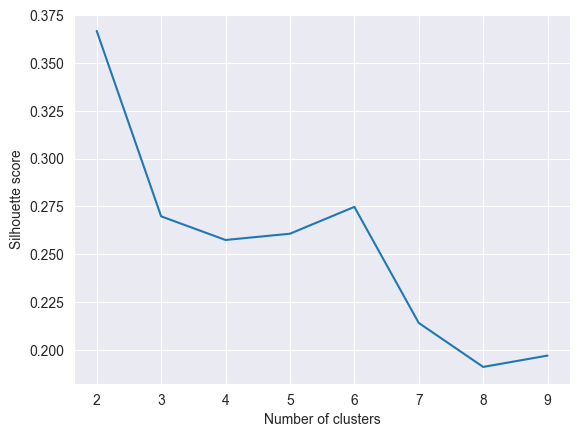

In [29]:
search_best_number_of_personae(features_scaled)

In [30]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(features_scaled)
selected_features['kmeans_label'] = labels
selected_features.head()

C:\Users\magda\AppData\Local\Temp\ipykernel_18072\2788476733.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_features['kmeans_label'] = labels


,persona,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count,kmeans_label
user_id,,,,,,,,,,,
2,Persona_3,0.904762,0.002632,23,0.058419,0.079038,5.82,13.660714,0.740741,30.742268,2
4,Persona_4,0.600000,0.000602,9,0.173913,0.000000,0.92,0.000000,1.000000,30.847826,3
6,Persona_5,1.481481,0.008620,29,0.033058,0.038017,12.10,11.503205,0.500000,31.447934,2
8,Persona_6,2.250000,0.001818,26,0.033113,0.036424,6.04,10.708333,0.687500,33.168874,2
9,Persona_6,0.500000,0.001995,3,0.076923,0.038462,0.52,0.000000,1.000000,31.307692,3


In [31]:
selected_features['kmeans_label'].value_counts()

kmeans_label
1    487
2    193
0     69
3     64
Name: count, dtype: int64

In [32]:
selected_features.drop(columns=['persona'], inplace=False).groupby('kmeans_label').mean()

,in_out_degree_ratio,betweenness,kcore,neutral_posts_ratio,negative_posts_ratio,posts_per_day,lifespan_mean,survival_rate,avg_word_count
kmeans_label,,,,,,,,,
0,0.519713,0.000625,4.739130,0.027010,0.197550,0.682899,1.153684,0.936467,34.056529
1,0.551408,0.000564,5.609856,0.020964,0.030803,0.937700,1.267470,0.922876,33.369269
2,1.093336,0.007543,22.637306,0.036601,0.049914,11.402591,13.567498,0.660647,32.233261
3,0.474333,0.000344,4.390625,0.128906,0.037431,0.594063,1.314779,0.936161,31.896934


### Compare with old personas

<Axes: xlabel='kmeans_label', ylabel='persona'>

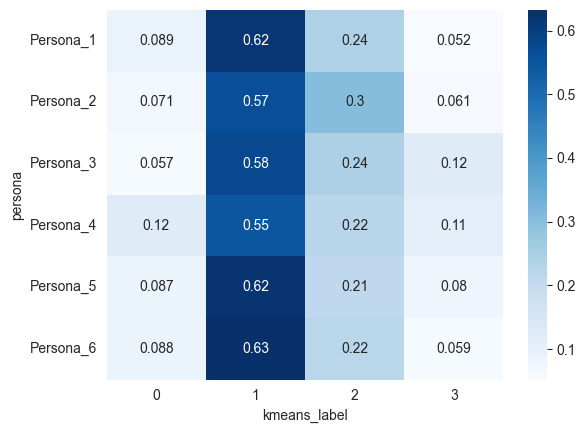

In [33]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='index')
sns.heatmap(tab, annot=True, cmap='Blues')

<Axes: xlabel='kmeans_label', ylabel='persona'>

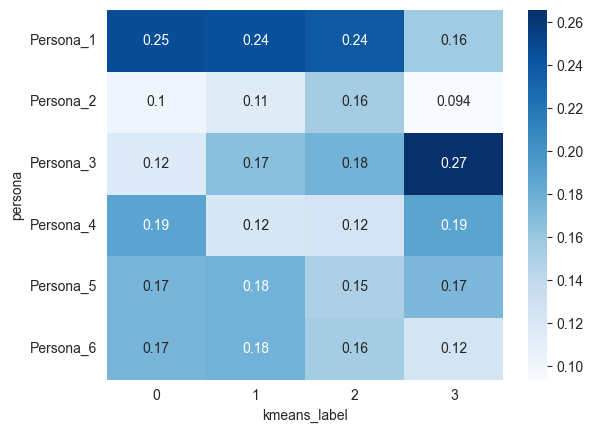

In [34]:
tab = pd.crosstab(selected_features['persona'], selected_features['kmeans_label'], normalize='columns')
sns.heatmap(tab, annot=True, cmap='Blues')

In [35]:
adjusted_rand_score(selected_features['persona'], selected_features['kmeans_label'])

0.002421085009144398

## Temporal stability of agents behaviour

In [36]:
window = 5
days = [10, 20, 35, 50]

### Follow

In [37]:
global_summary = []
summaries = []

for day in days:
    follow_t = follow[(follow['round'] <= day * 24) & (follow['round'] > (day - window) * 24)]
    print(len(follow_t))

    global_metrics, summary = build_graph_and_analyse(follow_t, persona_dict)
    global_metrics['day'] = day
    summary['day'] = day

    global_summary.append(global_metrics)
    summaries.append(summary)

global_summary_df = pd.concat(global_summary)
summaries_df = pd.concat(summaries)

1416
Graph creation ...

Number of nodes: 413
Number of edges: 963
Number of connective components: 40
Components sizes: [348, 2, 2, 1, 2, 1, 4, 2, 2, 1, 1, 1, 1, 1, 3, 2, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 2, 1, 1, 2, 3, 2, 1, 1, 2, 2, 2, 2, 2, 2]
Number of nodes (LCC): 348
Number of edges (LCC): 936

Global metrics ...

Mean degree: 4.66
Density: 0.0057
Diameter: 10
Avg. shortest path: 3.723
Modularity score: 0.445
Persona assortativity: 0.011243519477633194

Local metrics ...


Statistical check (metrics vs. persona) ...

in_degree statistics: p = 0.8045
out_degree statistics: p = 0.1960
total_degree statistics: p = 0.5651
betweenness statistics: p = 0.5592
eigenvector statistics: p = 0.8885
pagerank statistics: p = 0.9668
kcore statistics: p = 0.4087
1501
Graph creation ...

Number of nodes: 427
Number of edges: 1012
Number of connective components: 31
Components sizes: [377, 2, 3, 2, 2, 1, 1, 2, 2, 1, 1, 3, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 2]
Number of nodes (LCC):

In [38]:
rank_df = summaries_df.copy()

metrics = ['mean_in_degree', 'mean_out_degree', 'mean_total_degree', 'mean_betweenness', 'mean_eigenvector', 'mean_pagerank', 'mean_kcore']

for col in metrics:
    rank_df[col + '_rank'] = rank_df.groupby('day')[col] \
                                   .rank(ascending=False, method='min')

rank_summary = rank_df.groupby('persona')[[col + '_rank' for col in metrics]].agg(['mean', 'std'])

for metric in [col + '_rank' for col in metrics]:
    rank_summary[(metric, 'cv')] = (
        rank_summary[(metric, 'std')] /
        rank_summary[(metric, 'mean')]
    )

print(rank_summary)

          mean_in_degree_rank           mean_out_degree_rank            \
                         mean       std                 mean       std   
persona                                                                  
Persona_1                6.00  0.000000                 6.00  0.000000   
Persona_2                1.00  0.000000                 1.00  0.000000   
Persona_3                4.25  0.500000                 4.25  0.957427   
Persona_4                4.00  1.154701                 3.25  1.258306   
Persona_5                3.50  1.290994                 4.25  0.500000   
Persona_6                2.25  0.500000                 2.25  0.500000   

          mean_total_degree_rank           mean_betweenness_rank            \
                            mean       std                  mean       std   
persona                                                                      
Persona_1                   6.00  0.000000                  5.75  0.500000   
Persona_2            

### Posts

In [39]:
post_counts = []

for day in days:
    posts_t = posts[(posts['round'] <= day * 24) & (posts['round'] > (day - window) * 24)]
    print(len(posts_t))

    counts = posts_t.groupby('persona')['persona'].count().reset_index(name='count')
    counts = pd.DataFrame(counts)
    counts['ratio'] = counts['count'] / len(posts_t)
    counts['day'] = day
    post_counts.append(counts)

post_counts = pd.concat(post_counts)
post_counts

11531
11675
11609
11480


,persona,count,ratio,day
0,Persona_1,2152,0.186627,10
1,Persona_2,1950,0.169109,10
2,Persona_3,2026,0.175700,10
3,Persona_4,1703,0.147689,10
4,Persona_5,1418,0.122973,10
5,Persona_6,2282,0.197901,10
0,Persona_1,2210,0.189293,20
1,Persona_2,2061,0.176531,20
2,Persona_3,2086,0.178672,20
3,Persona_4,1585,0.135760,20


In [40]:
post_summary = post_counts[['persona', 'ratio']].groupby('persona').agg(
    mean_ratio=('ratio', 'mean'),
    std_ratio=('ratio', 'std')
)
post_summary['cv_ratio'] = (
    post_summary['std_ratio'] /
    post_summary['mean_ratio']
)

post_summary

,mean_ratio,std_ratio,cv_ratio
persona,,,
Persona_1,0.187855,0.006188,0.032940
Persona_2,0.171215,0.003621,0.021148
Persona_3,0.177399,0.007357,0.041474
Persona_4,0.136527,0.007905,0.057902
Persona_5,0.141302,0.013498,0.095528
Persona_6,0.185703,0.010005,0.053879


### Sentiment

In [41]:
sentiment_statistics = []

for day in days:
    posts_t = posts[(posts['round'] <= day * 24) & (posts['round'] > (day - window) * 24)]
    sentiment = posts_t.groupby('persona').agg(
        positive=('polarity_category', lambda x: (x == 'Positive').sum()),
        neutral=('polarity_category', lambda x: (x == 'Neutral').sum()),
        negative=('polarity_category', lambda x: (x == 'Negative').sum()),
        total=('polarity_category', 'count')
    ).reset_index()

    sentiment['positive_ratio'] = sentiment['positive'] / len(posts_t[posts_t['polarity_category'] == 'Positive'])
    sentiment['neutral_ratio'] = sentiment['neutral'] / len(posts_t[posts_t['polarity_category'] == 'Neutral'])
    sentiment['negative_ratio'] = sentiment['negative'] / len(posts_t[posts_t['polarity_category'] == 'Negative'])

    sentiment['total_ratio'] = sentiment['total'] / len(posts_t)
    sentiment['day'] = day
    sentiment_statistics.append(sentiment)

sentiment_statistics = pd.concat(sentiment_statistics)
sentiment_statistics

,persona,positive,neutral,negative,total,positive_ratio,neutral_ratio,negative_ratio,total_ratio,day
0,Persona_1,1972,89,91,2152,0.186884,0.188559,0.179487,0.186627,10
1,Persona_2,1788,72,90,1950,0.169447,0.152542,0.177515,0.169109,10
2,Persona_3,1848,96,82,2026,0.175133,0.203390,0.161736,0.175700,10
3,Persona_4,1549,67,87,1703,0.146797,0.141949,0.171598,0.147689,10
4,Persona_5,1291,66,61,1418,0.122346,0.139831,0.120316,0.122973,10
5,Persona_6,2104,82,96,2282,0.199393,0.173729,0.189349,0.197901,10
0,Persona_1,2043,61,106,2210,0.189606,0.163978,0.200758,0.189293,20
1,Persona_2,1936,55,70,2061,0.179675,0.147849,0.132576,0.176531,20
2,Persona_3,1935,63,88,2086,0.179582,0.169355,0.166667,0.178672,20
3,Persona_4,1454,46,85,1585,0.134942,0.123656,0.160985,0.135760,20


In [42]:
sentiment_statistics_sum = sentiment_statistics.groupby('persona')[['positive_ratio', 'neutral_ratio', 'negative_ratio', 'total_ratio']].agg(['mean', 'std'])

for metric in ['positive_ratio', 'neutral_ratio', 'negative_ratio', 'total_ratio']:
    sentiment_statistics_sum[(metric, 'cv')] = (
        sentiment_statistics_sum[(metric, 'std')] /
        sentiment_statistics_sum[(metric, 'mean')]
    )

print(sentiment_statistics_sum)

          positive_ratio           neutral_ratio           negative_ratio  \
                    mean       std          mean       std           mean   
persona                                                                     
Persona_1       0.187506  0.007167      0.181307  0.018815       0.198128   
Persona_2       0.173421  0.004505      0.138718  0.014700       0.152504   
Persona_3       0.177390  0.007385      0.192364  0.018066       0.164866   
Persona_4       0.135715  0.007748      0.133043  0.010401       0.155725   
Persona_5       0.139783  0.013333      0.168224  0.024727       0.151348   
Persona_6       0.186184  0.010679      0.186343  0.019500       0.177430   

                    total_ratio           positive_ratio neutral_ratio  \
                std        mean       std             cv            cv   
persona                                                                  
Persona_1  0.021572    0.187855  0.006188       0.038221      0.103773   
Persona_2 

### Plots over simulation time

#### Follows & unfollows

In [48]:
max_round = follow['round'].max()
print(f"Rounds: {max_round}")
print(f"Days: {max_round/24}")

round_iter = 24
counts_daily = []

while round_iter <= max_round:
    follow_r = follow[(follow['action'] == 'follow') &
                      (follow['round'] <= round_iter)]
    unfollow_r = follow[(follow['action'] == 'unfollow') &
                          (follow['round'] <= round_iter)]

    follows_per_persona = follow_r.groupby('persona').size().reset_index(name='n_follows')
    unfollows_per_persona = unfollow_r.groupby('persona').size().reset_index(name='n_unfollows')

    df = follows_per_persona.merge(unfollows_per_persona, on='persona', how='outer').fillna(0)

    df['day'] = round_iter / 24

    counts_daily.append(df)

    round_iter += 24 # 1 round = 1 hour

follows_daily = pd.concat(counts_daily, ignore_index=True)
follows_daily

Rounds: 1440
Days: 60.0


,persona,n_follows,n_unfollows,day
0,Persona_1,27,3,1.0
1,Persona_2,26,4,1.0
2,Persona_3,23,4,1.0
3,Persona_4,15,1,1.0
4,Persona_5,15,5,1.0
...,...,...,...,...
355,Persona_2,2027,840,60.0
356,Persona_3,2245,769,60.0
357,Persona_4,1692,662,60.0
358,Persona_5,1822,582,60.0


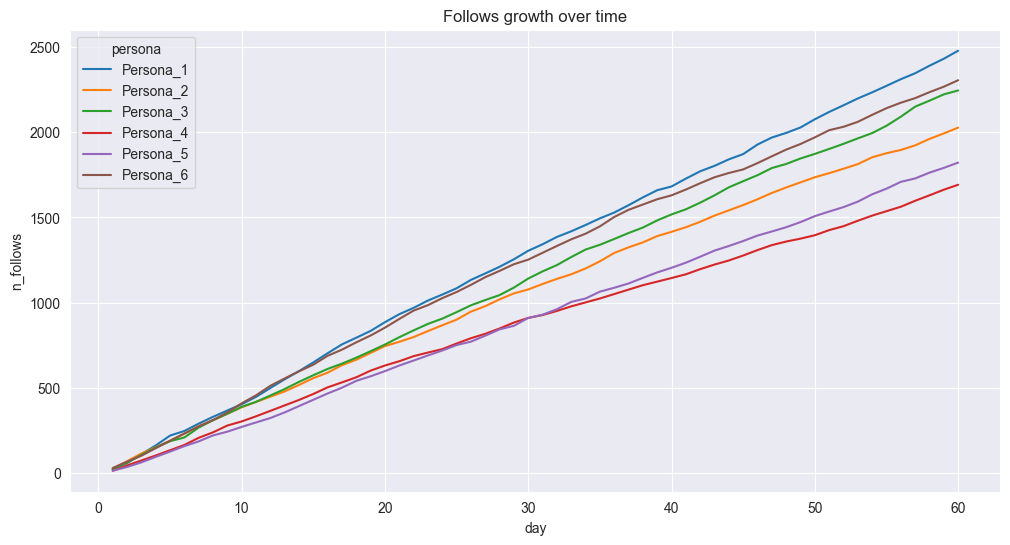

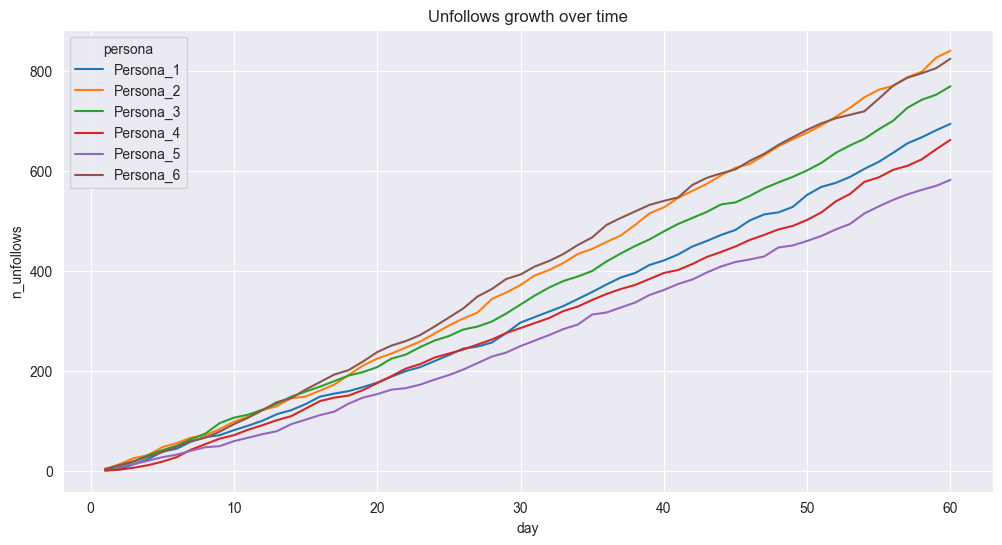

In [49]:
plt.figure(figsize = (12,6))

sns.lineplot(
    data=follows_daily,
    x='day',
    y='n_follows',
    hue='persona'
)

plt.title('Follows growth over time')
plt.show()

plt.figure(figsize = (12,6))

sns.lineplot(
    data=follows_daily,
    x='day',
    y='n_unfollows',
    hue='persona'
)

plt.title('Unfollows growth over time')
plt.show()

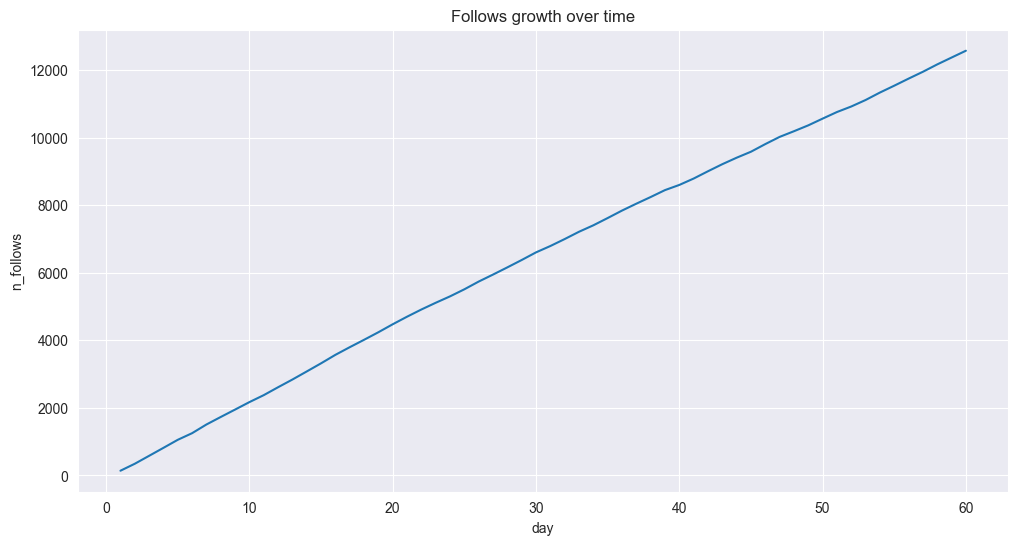

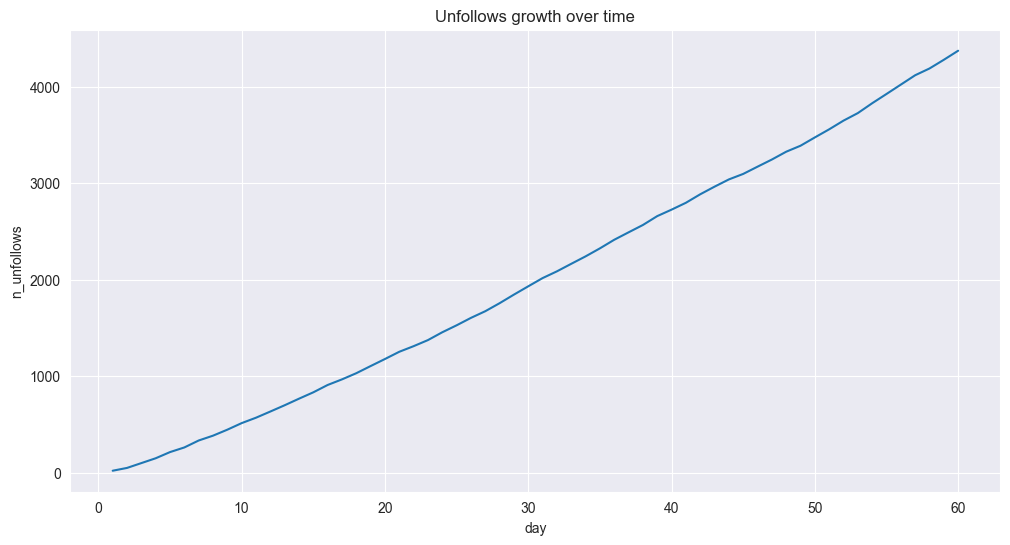

In [50]:
follows_daily_sum = follows_daily.groupby('day').agg(
    n_follows=('n_follows', 'sum'),
    n_unfollows=('n_unfollows', 'sum')
).reset_index()

plt.figure(figsize = (12,6))

sns.lineplot(
    data=follows_daily_sum,
    x='day',
    y='n_follows'
)

plt.title('Follows growth over time')
plt.show()

plt.figure(figsize = (12,6))

sns.lineplot(
    data=follows_daily_sum,
    x='day',
    y='n_unfollows'
)

plt.title('Unfollows growth over time')
plt.show()

In [52]:
# follows_daily_sum.to_csv('data/exp_set_1/follows_daily_sum.csv')

#### Posts

In [53]:
round_iter = 24
counts_daily = []

while round_iter <= max_round:
    posts_r = posts[posts['round'] <= round_iter]

    posts_per_persona = posts_r.groupby('persona').size().reset_index(name='n_posts')
    posts_per_persona['day'] = round_iter / 24

    counts_daily.append(posts_per_persona)
    round_iter += 24 # 1 round = 1 hour

posts_daily = pd.concat(counts_daily, ignore_index=True)

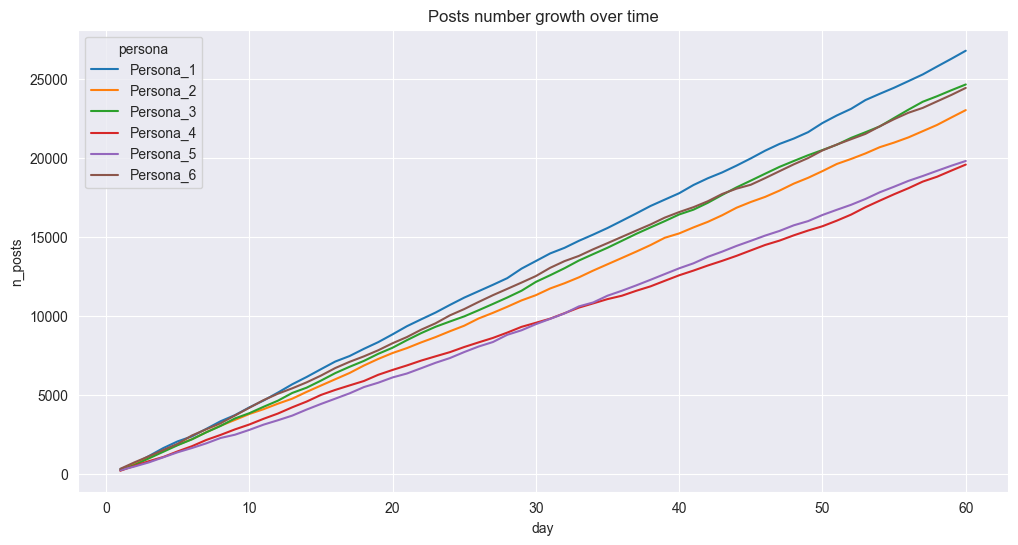

In [54]:
plt.figure(figsize = (12,6))

sns.lineplot(
    data=posts_daily,
    x='day',
    y='n_posts',
    hue='persona'
)

plt.title('Posts number growth over time')
plt.show()

In [59]:
posts_daily_sum = posts_daily.groupby('day').agg(
    n_posts=('n_posts', 'sum')
)
list(posts_daily_sum['n_posts'])

,n_posts
day,
1.0,1475
2.0,3539
3.0,5766
4.0,8104
5.0,10379
6.0,12546
7.0,14997
8.0,17342
9.0,19614


#### Neighborhood